In [21]:
import pandas as pd
import numpy as np

#pull data
data = pd.read_csv(r'Dataset\GOOG.csv')
print(data.head())

         Date      Open      High       Low     Close  Adj Close     Volume
0  2004-08-19  2.490664  2.591785  2.390042  2.499133   2.499133  897427216
1  2004-08-20  2.515820  2.716817  2.503118  2.697639   2.697639  458857488
2  2004-08-23  2.758411  2.826406  2.716070  2.724787   2.724787  366857939
3  2004-08-24  2.770615  2.779581  2.579581  2.611960   2.611960  306396159
4  2004-08-25  2.614201  2.689918  2.587302  2.640104   2.640104  184645512


In [22]:
#checking data
print('Dataset Information :')
print(data.info())

Dataset Information :
<class 'pandas.DataFrame'>
RangeIndex: 4858 entries, 0 to 4857
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       4858 non-null   str    
 1   Open       4858 non-null   float64
 2   High       4858 non-null   float64
 3   Low        4858 non-null   float64
 4   Close      4858 non-null   float64
 5   Adj Close  4858 non-null   float64
 6   Volume     4858 non-null   int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 265.8 KB
None


In [4]:
# Check missing values
print("\nMissing values per fitur:")
print(data.isnull().sum())


Missing values per fitur:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [7]:
#Change date
data['Date'] = pd.to_datetime(data['Date'])
data = data.sort_values('Date')

#recheck missing values
print("\nMissing values per fitur:")
print(data.isnull().sum())


Missing values per fitur:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [11]:
#lets transform this data to log return
data['log_return'] = np.log(
    data['Adj Close'] / data['Adj Close'].shift(1)
)

#check the transformation
print(data.head(10))
print(data.tail())

        Date      Open      High       Low     Close  Adj Close     Volume  \
0 2004-08-19  2.490664  2.591785  2.390042  2.499133   2.499133  897427216   
1 2004-08-20  2.515820  2.716817  2.503118  2.697639   2.697639  458857488   
2 2004-08-23  2.758411  2.826406  2.716070  2.724787   2.724787  366857939   
3 2004-08-24  2.770615  2.779581  2.579581  2.611960   2.611960  306396159   
4 2004-08-25  2.614201  2.689918  2.587302  2.640104   2.640104  184645512   
5 2004-08-26  2.613952  2.688672  2.606729  2.687676   2.687676  142572401   
6 2004-08-27  2.692408  2.705360  2.632383  2.643840   2.643840  124826132   
7 2004-08-30  2.622171  2.627402  2.540727  2.540727   2.540727  104429967   
8 2004-08-31  2.547950  2.583068  2.544463  2.549693   2.549693   98825037   
9 2004-09-01  2.557912  2.564637  2.482445  2.496891   2.496891  183633734   

   log_return  
0         NaN  
1    0.076433  
2    0.010013  
3   -0.042289  
4    0.010717  
5    0.017859  
6   -0.016444  
7   -0.039782

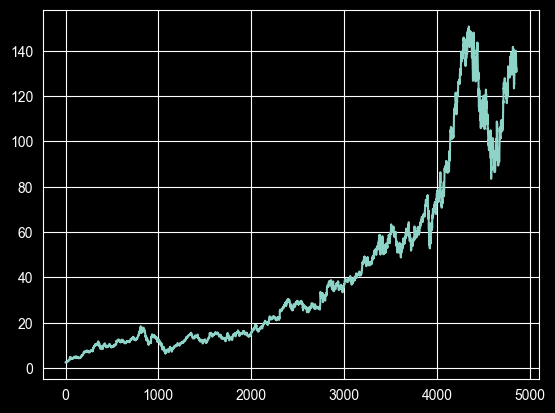

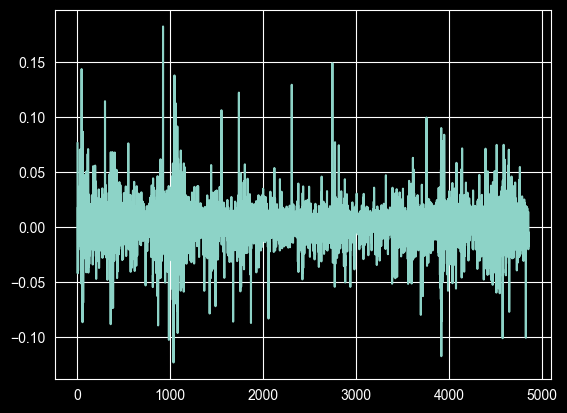

In [20]:
#lets visualize
import matplotlib.pyplot as plt

data['Adj Close'].plot()
plt.show()
data['log_return'].plot()
plt.show()


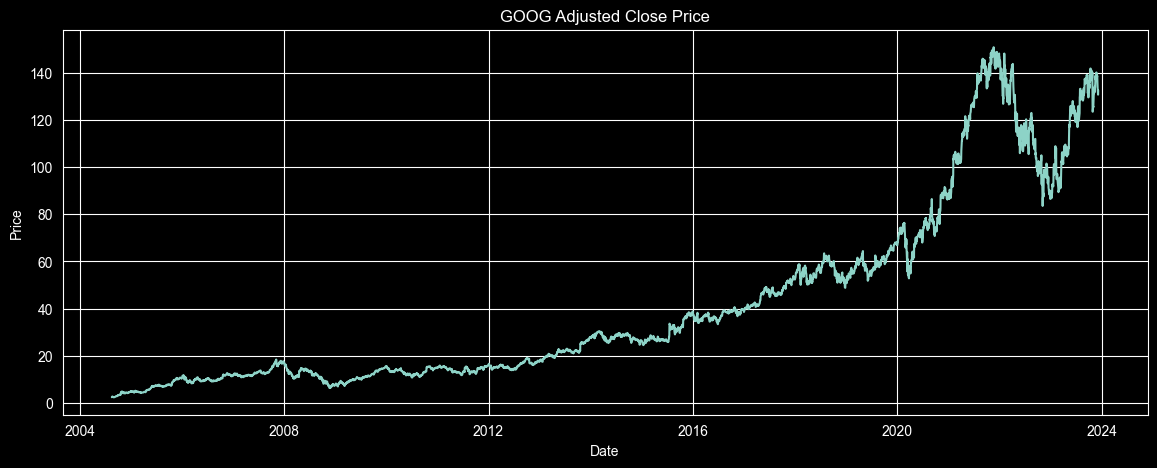

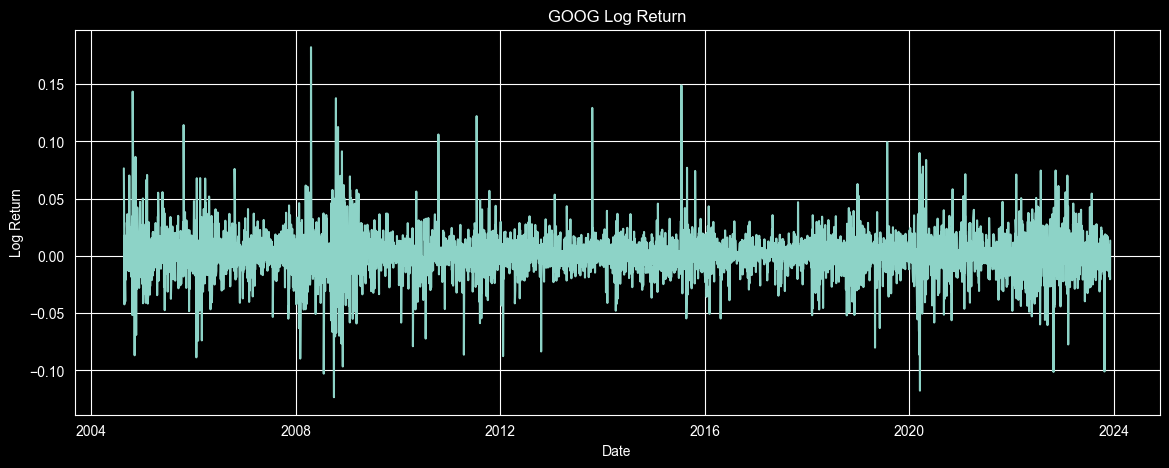

In [19]:

#timexprice
plt.figure(figsize=(14,5))

plt.plot(
    data['Date'],
    data['Adj Close']
)

plt.title('GOOG Adjusted Close Price')
plt.xlabel('Date')
plt.ylabel('Price')

plt.show()

#timexpriceLog
plt.figure(figsize=(14,5))

plt.plot(
    data['Date'],
    data['log_return']
)

plt.title('GOOG Log Return')
plt.xlabel('Date')
plt.ylabel('Log Return')

plt.grid(True)

plt.show()

<Axes: >

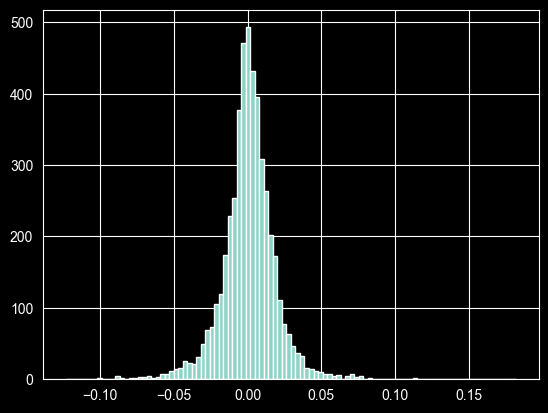

In [15]:
data['log_return'].hist(bins=100)